# Tripartite Population Dynamics

### Imports

In [3]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

## test analysis

In [4]:
from src.parameters import parameters
print(parameters)


{'beta': 0.0001, 'gamma': 0.0001, 'alpha': 0.0002, 'eta': 0.0001, 'r_c': 0.5, 'r_p': 0.2, 'nu': 0.0001, 'sigma_c': 0.1, 'sigma_p': 0.1}


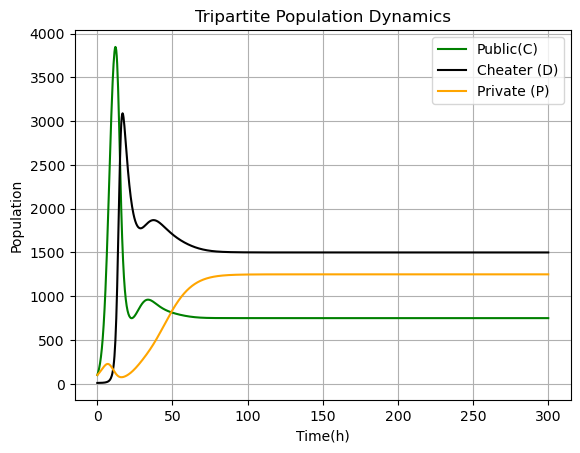

In [5]:
y0 =100.0, 10.0, 100.0
t = np.linspace(0,300,1000)
ret = odeint(deriv,y0,t,args=(
parameters["nu"],
parameters["beta"],
parameters["alpha"],
parameters["r_c"],
parameters["r_p"],
parameters["gamma"],
parameters["eta"],
))

# Plot results
plt.figure()
plt.plot(t, ret[:, 0], label="Public(C)", color='green')
plt.plot(t, ret[:, 1], label="Cheater (D)",color='black' )
plt.plot(t, ret[:, 2], label="Private (P)", color='orange')
plt.xlabel("Time(h)")
plt.ylabel("Population")
plt.title("Tripartite Population Dynamics")
plt.legend()
plt.grid()
plt.savefig("output/figures/fig1.png", dpi=300)
plt.show()

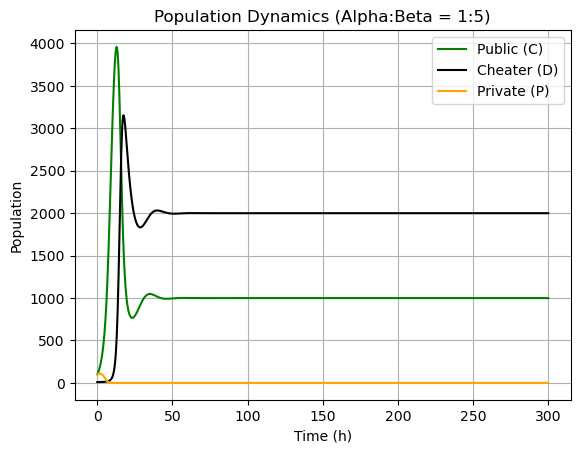

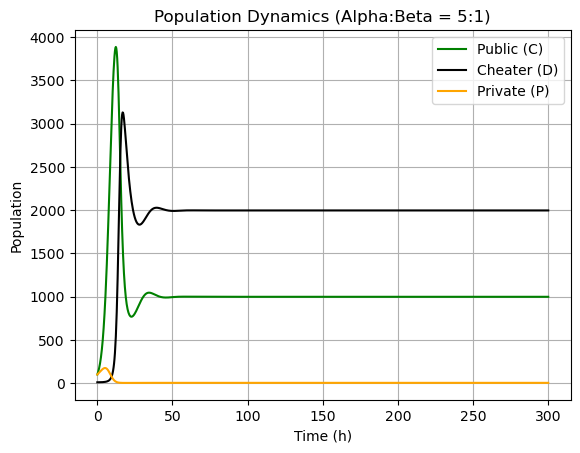

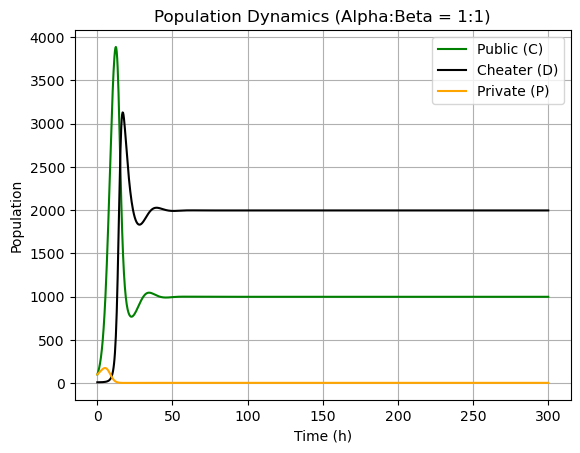

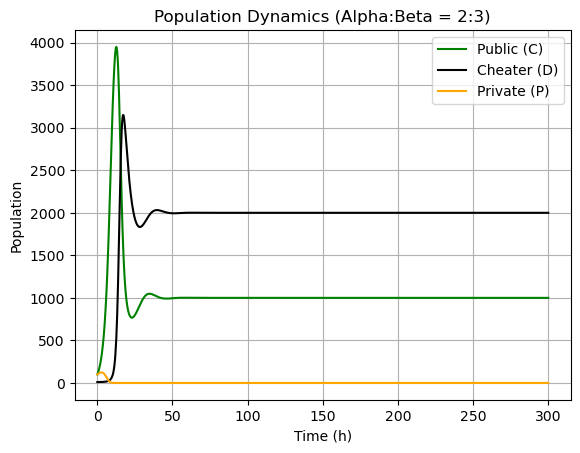

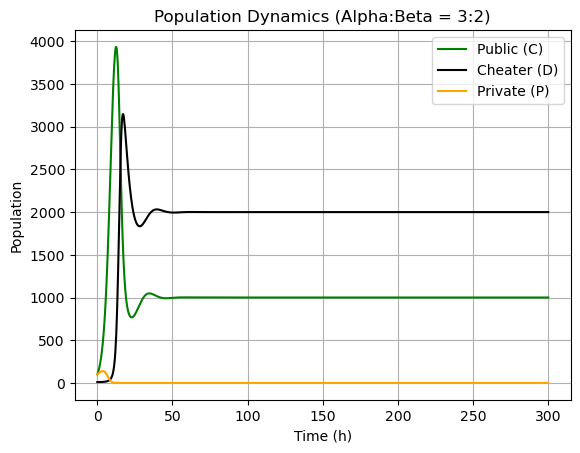

In [8]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

# Initial conditions and time vector
y0 = 100.0, 10.0, 100.0  # Initial populations of C, D, P
t = np.linspace(0, 300, 1000)  # Time range for simulation

# Define alpha:beta ratios to test
ratios = [(1, 5), (5, 1), (1, 1), (2, 3), (3, 2)]  # Example ratios

# Create output directory if not exists
output_dir = "output/figures"
os.makedirs(output_dir, exist_ok=True)

# Reference alpha from parameters
base_alpha = parameters["alpha"]

# Run simulations for different alpha:beta ratios
for ratio in ratios:
    alpha_ratio, beta_multiplier = ratio
    alpha = base_alpha  # Keep alpha unchanged as in the parameters
    beta = alpha * beta_multiplier  # Scale beta relative to alpha

    # Run the simulation
    ret = odeint(
        deriv, y0, t, args=(
            parameters["nu"],
            beta,
            alpha,
            parameters["r_c"],
            parameters["r_p"],
            parameters["gamma"],
            parameters["eta"],
        )
    )

    # Plot results for the current ratio
    plt.figure()
    plt.plot(t, ret[:, 0], label="Public (C)", color='green')
    plt.plot(t, ret[:, 1], label="Cheater (D)", color='black')
    plt.plot(t, ret[:, 2], label="Private (P)", color='orange')
    plt.xlabel("Time (h)")
    plt.ylabel("Population")
    plt.title(f"Population Dynamics (Alpha:Beta = {alpha_ratio}:{beta_multiplier})")
    plt.legend()
    plt.grid()
    plt.show()

    # Save the figure
    plt.savefig(f"{output_dir}/fig_alpha{alpha_ratio}_beta{beta_multiplier}.png", dpi=300)
    plt.close()

   
    

    
    

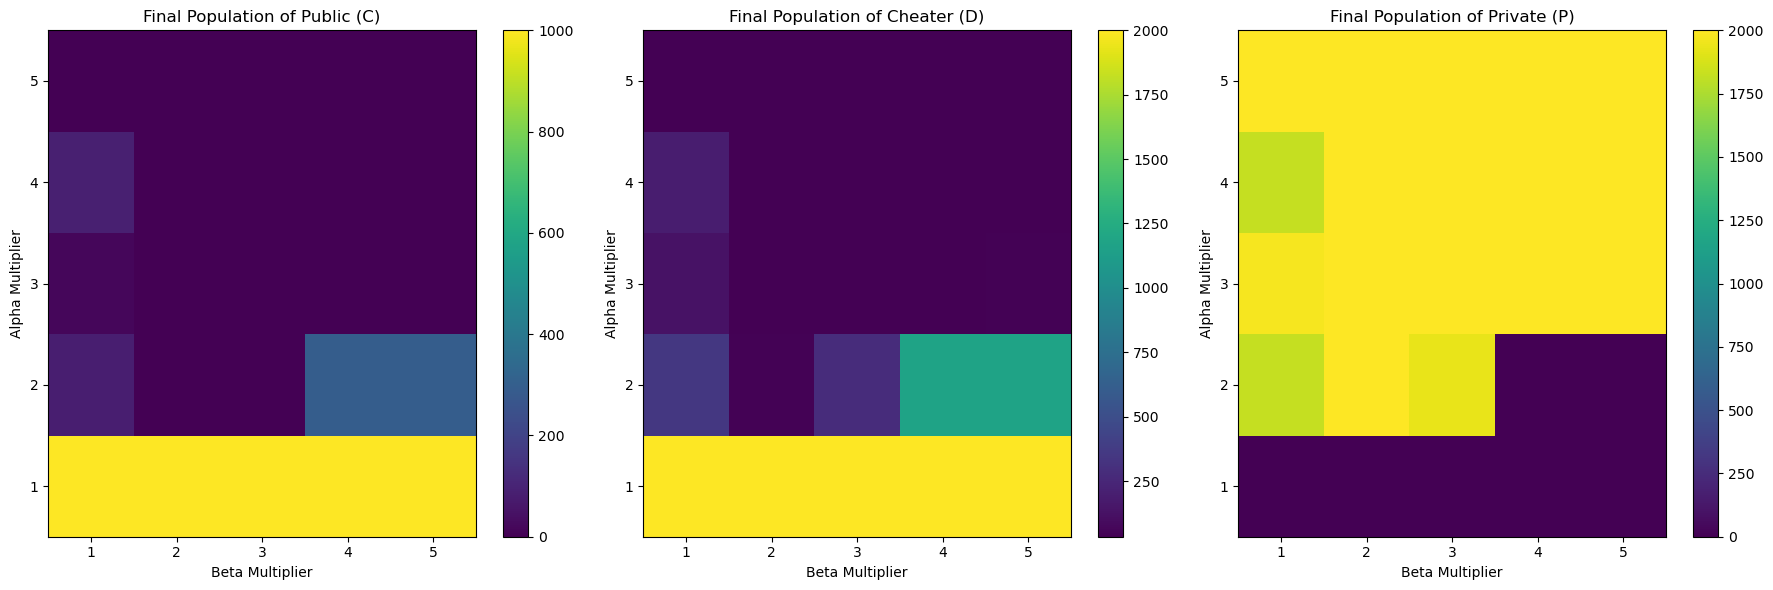

In [9]:
from src.model import deriv
from src.parameters import parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Initial conditions and time vector
y0 = 100.0, 10.0, 100.0  # Initial populations of C, D, P
t = np.linspace(0, 300, 1000)  # Time range for simulation

# Define alpha and beta multipliers for heatmap
alpha_multipliers = [1, 2, 3, 4, 5]  # Scale factors for alpha
beta_multipliers = [1, 2, 3, 4, 5]  # Scale factors for beta

# Reference alpha from parameters
base_alpha = parameters["alpha"]
base_beta = parameters["beta"]

# Create a matrix to store results
results_C = np.zeros((len(alpha_multipliers), len(beta_multipliers)))  # For Public (C)
results_D = np.zeros((len(alpha_multipliers), len(beta_multipliers)))  # For Cheater (D)
results_P = np.zeros((len(alpha_multipliers), len(beta_multipliers)))  # For Private (P)

# Simulate for each combination of alpha and beta
for i, alpha_mult in enumerate(alpha_multipliers):
    for j, beta_mult in enumerate(beta_multipliers):
        alpha = base_alpha * alpha_mult
        beta = base_alpha * beta_mult

        # Run the simulation
        ret = odeint(
            deriv, y0, t, args=(
                parameters["nu"],
                beta,
                alpha,
                parameters["r_c"],
                parameters["r_p"],
                parameters["gamma"],
                parameters["eta"],
            )
        )

        # Use the final population values for heatmap
        results_C[i, j] = ret[-1, 0]  # Final Public (C)
        results_D[i, j] = ret[-1, 1]  # Final Cheater (D)
        results_P[i, j] = ret[-1, 2]  # Final Private (P)

# Plot the heatmaps
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap for Public (C)
c1 = axs[0].imshow(results_C, aspect='auto', cmap='viridis', origin='lower')
axs[0].set_title('Final Population of Public (C)')
axs[0].set_xlabel('Beta Multiplier')
axs[0].set_ylabel('Alpha Multiplier')
axs[0].set_xticks(range(len(beta_multipliers)))
axs[0].set_xticklabels(beta_multipliers)
axs[0].set_yticks(range(len(alpha_multipliers)))
axs[0].set_yticklabels(alpha_multipliers)
fig.colorbar(c1, ax=axs[0])

# Heatmap for Cheater (D)
c2 = axs[1].imshow(results_D, aspect='auto', cmap='viridis', origin='lower')
axs[1].set_title('Final Population of Cheater (D)')
axs[1].set_xlabel('Beta Multiplier')
axs[1].set_ylabel('Alpha Multiplier')
axs[1].set_xticks(range(len(beta_multipliers)))
axs[1].set_xticklabels(beta_multipliers)
axs[1].set_yticks(range(len(alpha_multipliers)))
axs[1].set_yticklabels(alpha_multipliers)
fig.colorbar(c2, ax=axs[1])

# Heatmap for Private (P)
c3 = axs[2].imshow(results_P, aspect='auto', cmap='viridis', origin='lower')
axs[2].set_title('Final Population of Private (P)')
axs[2].set_xlabel('Beta Multiplier')
axs[2].set_ylabel('Alpha Multiplier')
axs[2].set_xticks(range(len(beta_multipliers)))
axs[2].set_xticklabels(beta_multipliers)
axs[2].set_yticks(range(len(alpha_multipliers)))
axs[2].set_yticklabels(alpha_multipliers)
fig.colorbar(c3, ax=axs[2])

# Save and show the heatmap
plt.tight_layout()
plt.savefig("output/figures/heatmap_alpha_beta.png", dpi=300)
plt.show()


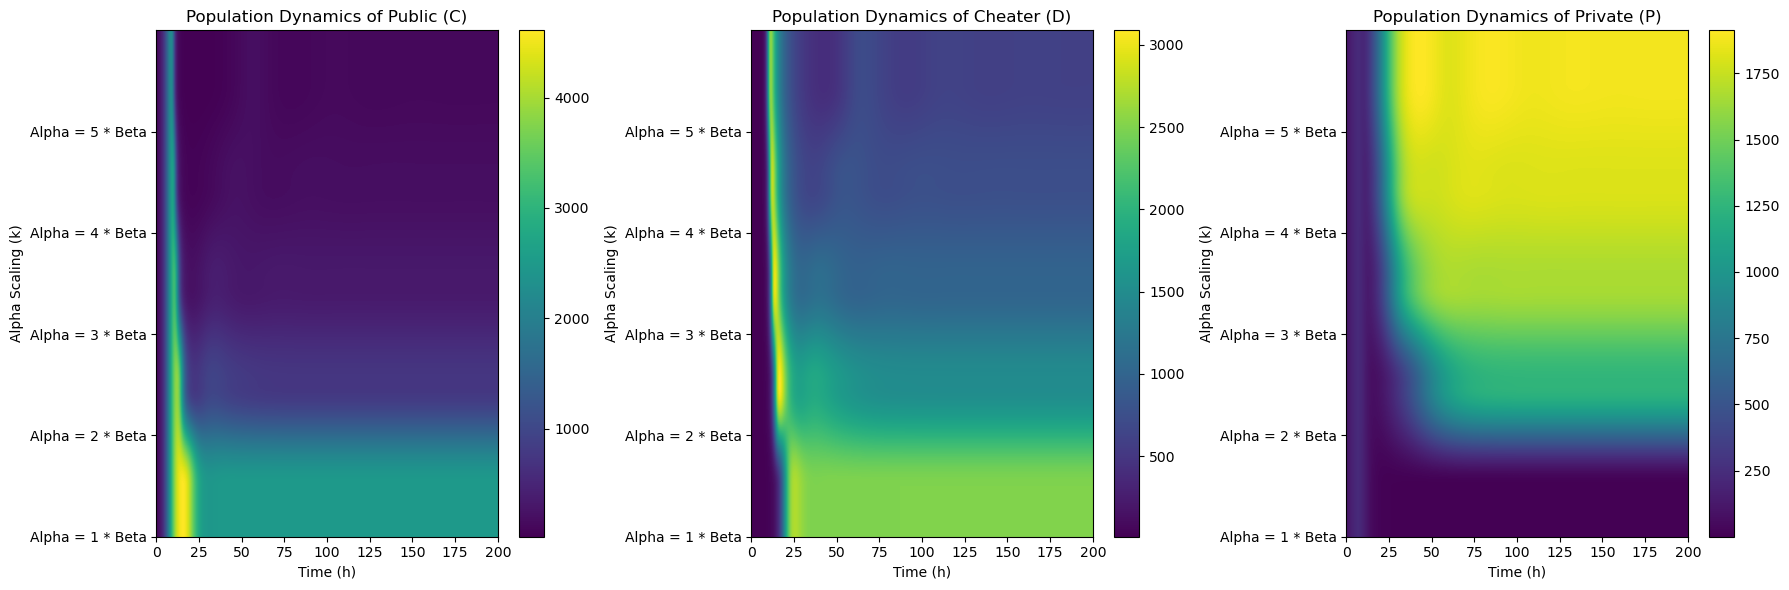

In [15]:
from src.model import deriv
from src.parameters import parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Initial conditions and time vector
y0 = 100.0, 10.0, 100.0  # Initial populations of C, D, P
t = np.linspace(0, 200, 1000)  # Time range for simulation

# Define alpha scaling factors
alpha_multipliers = [1, 2, 3, 4, 5]  # Alpha = k * Beta

# Reference beta from parameters
base_beta = parameters["beta"]

# Matrices to store results for heatmap
pop_C = np.zeros((len(alpha_multipliers), len(t)))  # Public (C) over time for each scaling
pop_D = np.zeros((len(alpha_multipliers), len(t)))  # Cheater (D) over time for each scaling
pop_P = np.zeros((len(alpha_multipliers), len(t)))  # Private (P) over time for each scaling

# Simulate for each scaling of alpha
for i, alpha_mult in enumerate(alpha_multipliers):
    alpha = base_beta * alpha_mult  # Scale alpha
    beta = base_beta  # Keep beta constant

    # Run the simulation
    ret = odeint(
        deriv, y0, t, args=(
            parameters["nu"],
            beta,
            alpha,
            parameters["r_c"],
            parameters["r_p"],
            parameters["gamma"],
            parameters["eta"],
        )
    )

    # Store population data for heatmap
    pop_C[i, :] = ret[:, 0]  # Public (C)
    pop_D[i, :] = ret[:, 1]  # Cheater (D)
    pop_P[i, :] = ret[:, 2]  # Private (P)

# Plot heatmaps for each population
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap for Public (C)
c1 = axs[0].imshow(pop_C, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(alpha_multipliers) + 1])
axs[0].set_title('Population Dynamics of Public (C)')
axs[0].set_xlabel('Time (h)')
axs[0].set_ylabel('Alpha Scaling (k)')
axs[0].set_yticks(range(1, len(alpha_multipliers) + 1))
axs[0].set_yticklabels([f"Alpha = {k} * Beta" for k in alpha_multipliers])
fig.colorbar(c1, ax=axs[0])

# Heatmap for Cheater (D)
c2 = axs[1].imshow(pop_D, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(alpha_multipliers) + 1])
axs[1].set_title('Population Dynamics of Cheater (D)')
axs[1].set_xlabel('Time (h)')
axs[1].set_ylabel('Alpha Scaling (k)')
axs[1].set_yticks(range(1, len(alpha_multipliers) + 1))
axs[1].set_yticklabels([f"Alpha = {k} * Beta" for k in alpha_multipliers])
fig.colorbar(c2, ax=axs[1])

# Heatmap for Private (P)
c3 = axs[2].imshow(pop_P, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(alpha_multipliers) + 1])
axs[2].set_title('Population Dynamics of Private (P)')
axs[2].set_xlabel('Time (h)')
axs[2].set_ylabel('Alpha Scaling (k)')
axs[2].set_yticks(range(1, len(alpha_multipliers) + 1))
axs[2].set_yticklabels([f"Alpha = {k} * Beta" for k in alpha_multipliers])
fig.colorbar(c3, ax=axs[2])

# Save and show the heatmaps
plt.tight_layout()
plt.savefig("output/figures/heatmap_alpha_scaled.png", dpi=300)
plt.show()


# 1. Simulating with different initial ratio(cheater 1:5:10)


In [4]:
# Define initial conditions for different ratios
ratios = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "1:5:1": [100.0, 500.0, 100.0],
    "1:10:1": [100.0, 1000.0, 100.0],
}

# Time points
t = np.linspace(0, 200, 500)

# Ensure output directory exists
os.makedirs("output/figures", exist_ok=True)

# Define colors for populations and line styles for ratios
colors = {"Public (C)": "green", "Cheater (D)": "black", "Private (P)": "orange"}
line_styles = {
    "1:1:1": "-",
    "1:5:1": "--",
    "1:10:1": ":",
}

def simulate_population(t, ratios, colors, line_styles, parameters, save_name_suffix):

    for population, idx in zip(["Public (C)", "Cheater (D)", "Private (P)"], range(3)):
        plt.figure(figsize=(10, 6))
        for label, y0 in ratios.items():
            # Solve the system of ODEs
            ret = odeint(deriv, y0, t, args=(
                parameters["nu"],
                parameters["beta"],
                parameters["alpha"],
                parameters["r_c"],
                parameters["r_p"],
                parameters["gamma"],
                parameters["eta"],
            ))
            
            # Plot the specific population with the correct color and line style
            legend_label = f"Public:Cheater:Private - {label}"
            plt.plot(
                t, ret[:, idx],
                color=colors[population],  # Correct color applied here
                linestyle=line_styles[label],  # Line style for the ratio
                label=legend_label
            )

        # Customize the plot
        plt.xlabel("Time(h)", fontsize=14, fontweight="bold")
        plt.ylabel("Population(cell)", fontsize=14,fontweight="bold" )
        plt.title(f"{population} Population Dynamics", fontsize=16)
        plt.legend(title="Initial Ratios", fontsize=10)
        plt.grid()
        plt.tight_layout()

        # Save the figure with a suffix to distinguish results
        output_file = f"output/figures/{population.replace(' ', '_').lower()}_{save_name_suffix}.png"
        plt.savefig(output_file, dpi=300)
        plt.show()


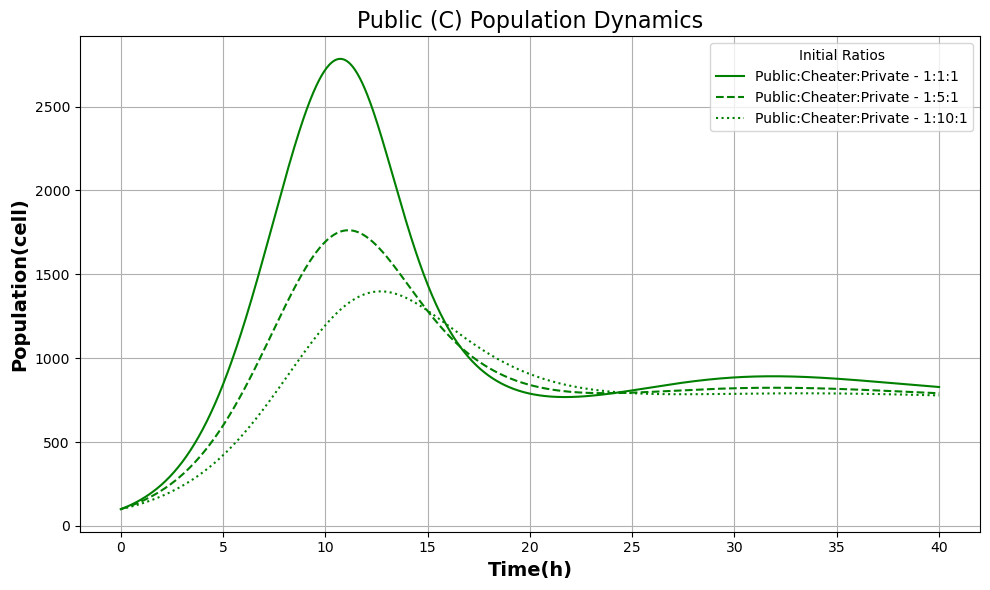

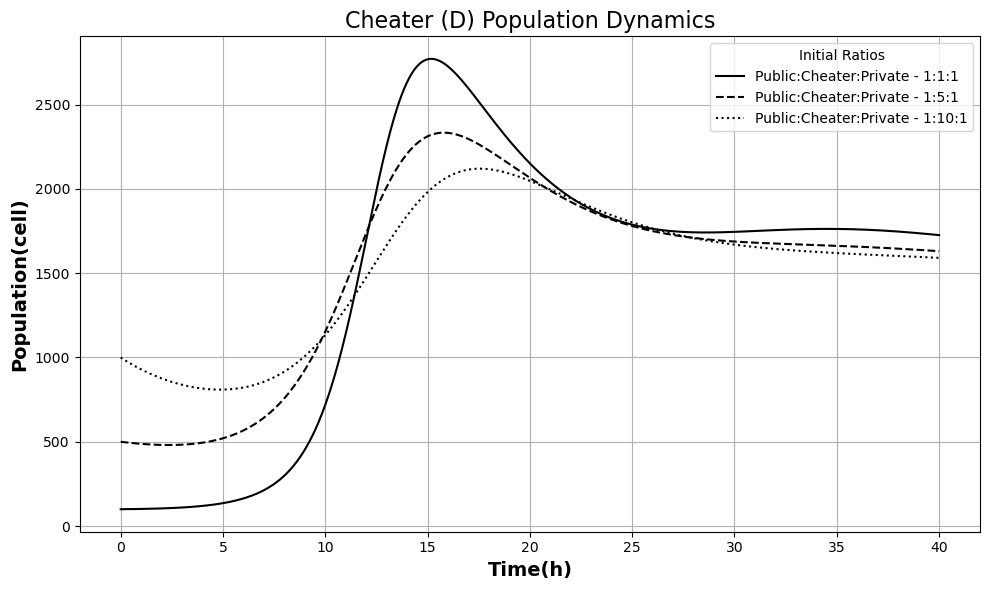

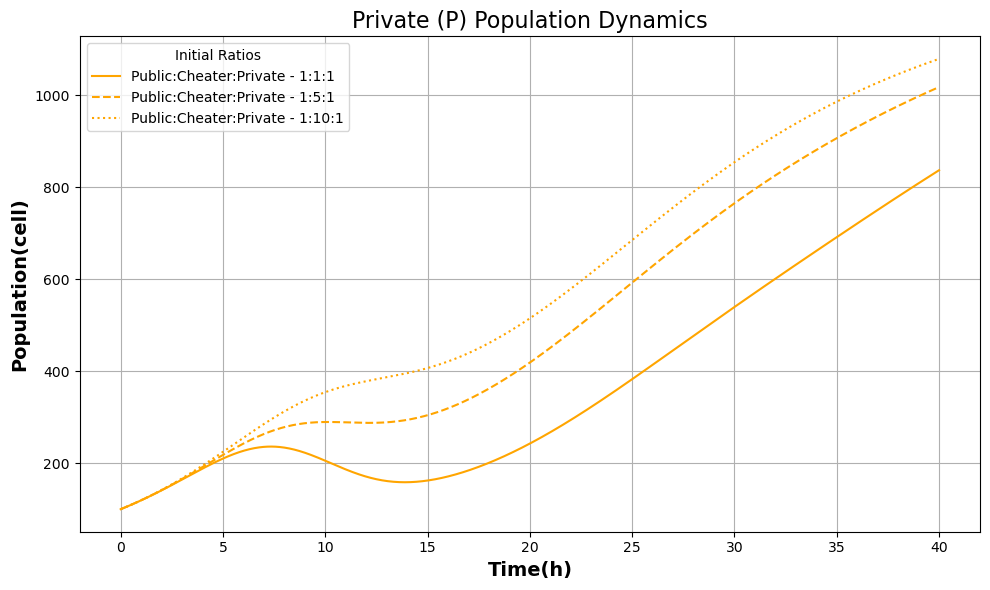

In [5]:
t_updated = np.linspace(0, 40, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="cheater_ra")

## longer time period

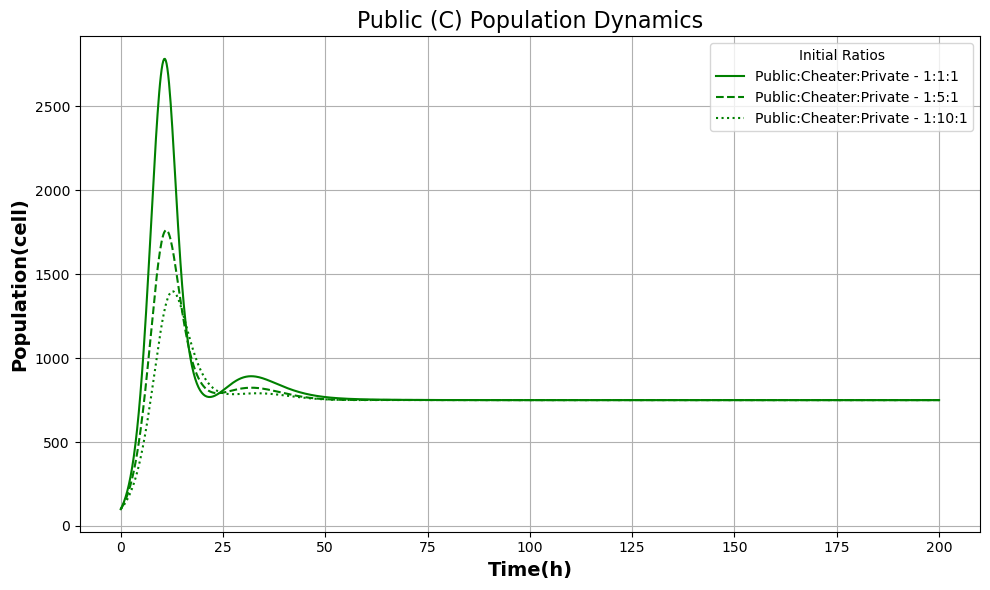

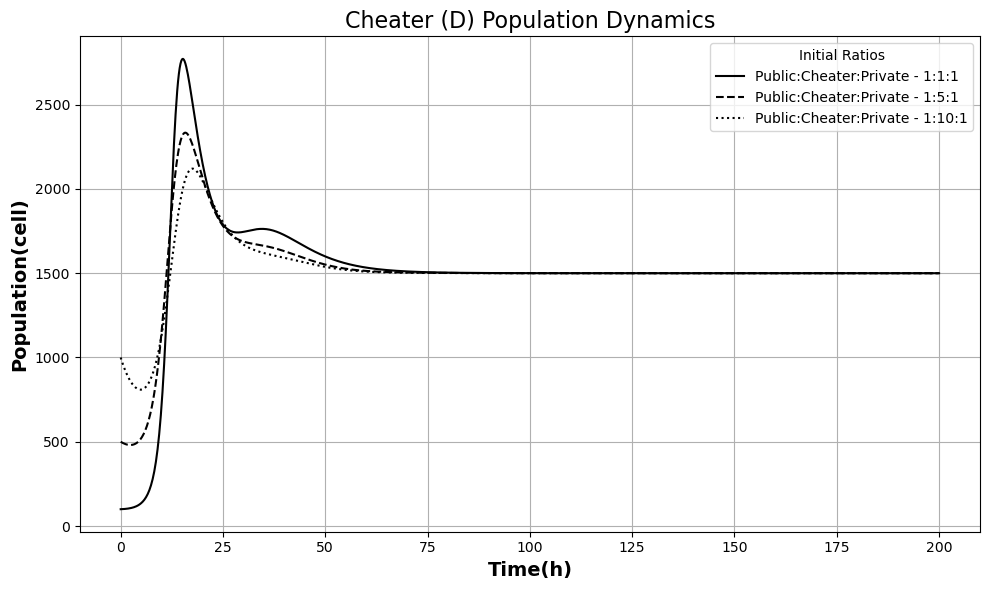

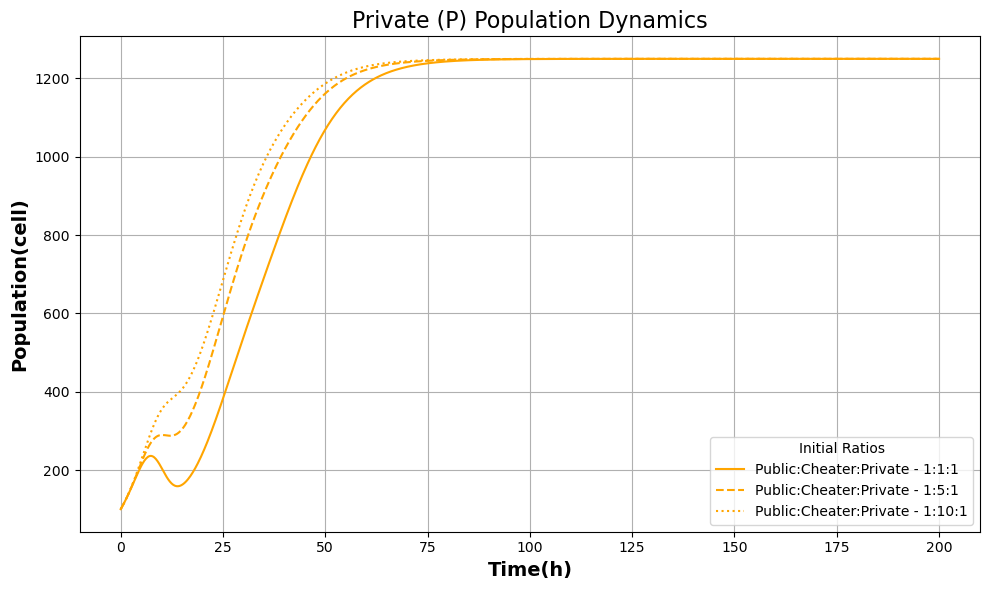

In [6]:
t_updated = np.linspace(0, 200, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="updated_time")

## higher ratio of public population(1:5:10)

In [7]:
# Updated ratios: Public (C) has initial ratio of 1, 5, and 10
ratios_updated = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "5:1:1": [500.0, 100.0, 100.0],
    "10:1:1": [1000.0, 100.0, 100.0],
}

line_styles = {
    "1:1:1": "-",
    "5:1:1": "--",
    "10:1:1": ":",
}


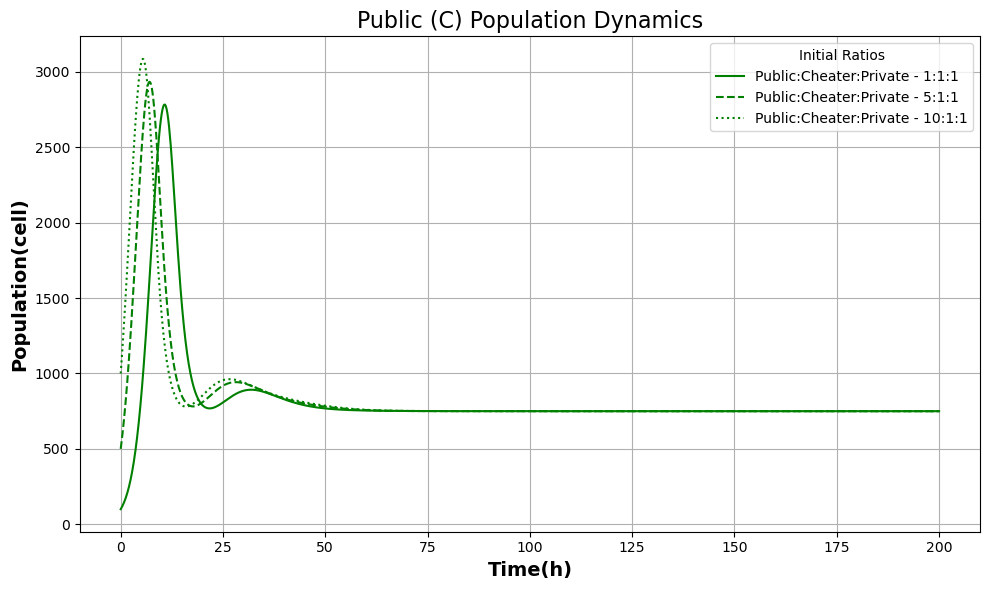

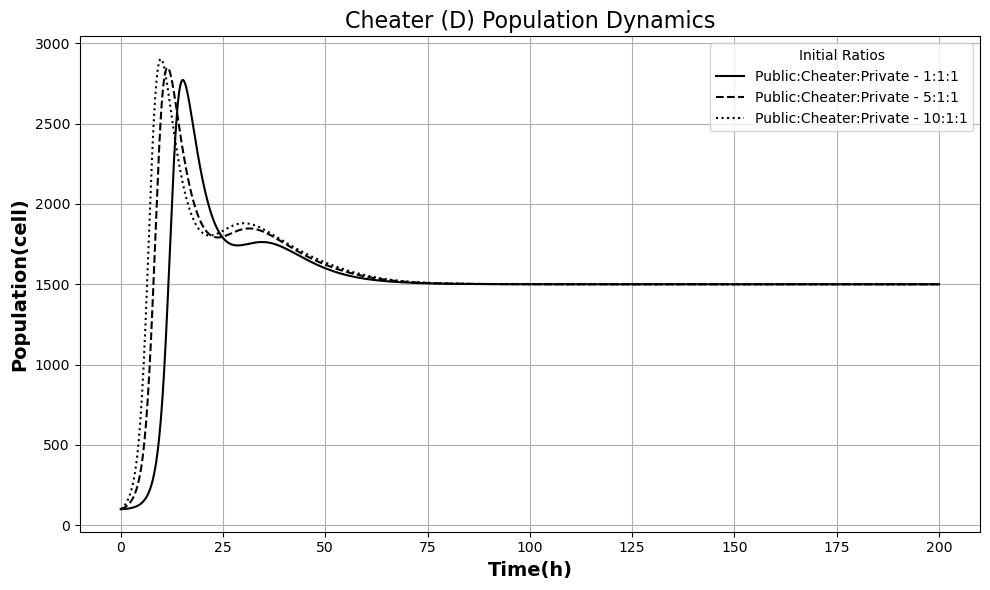

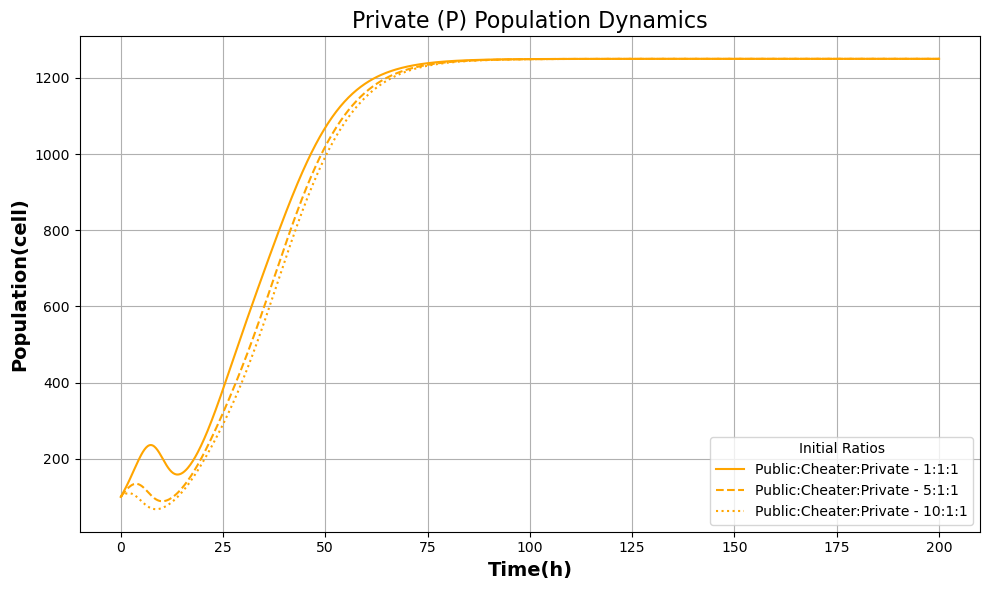

In [8]:
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

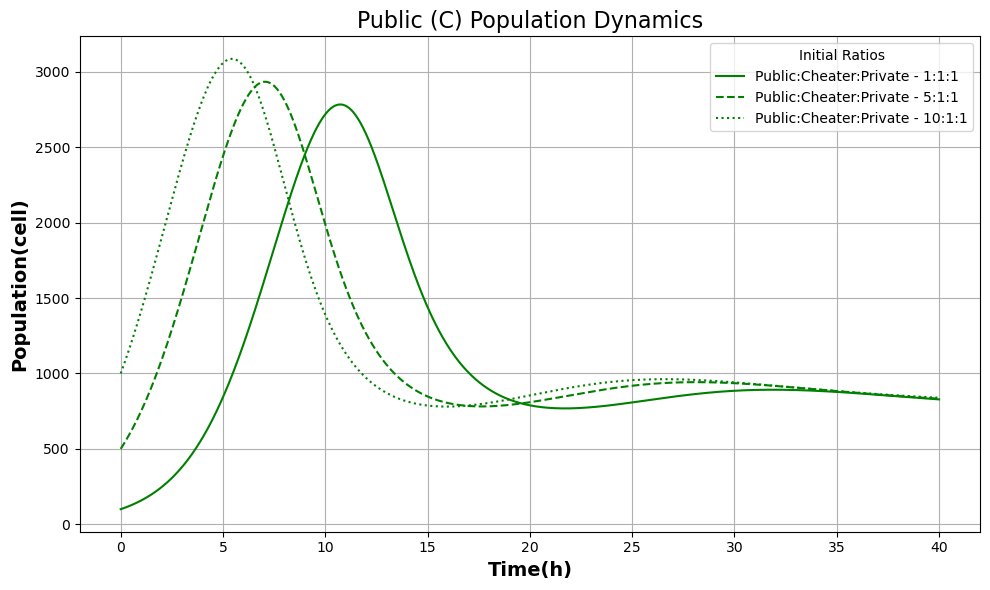

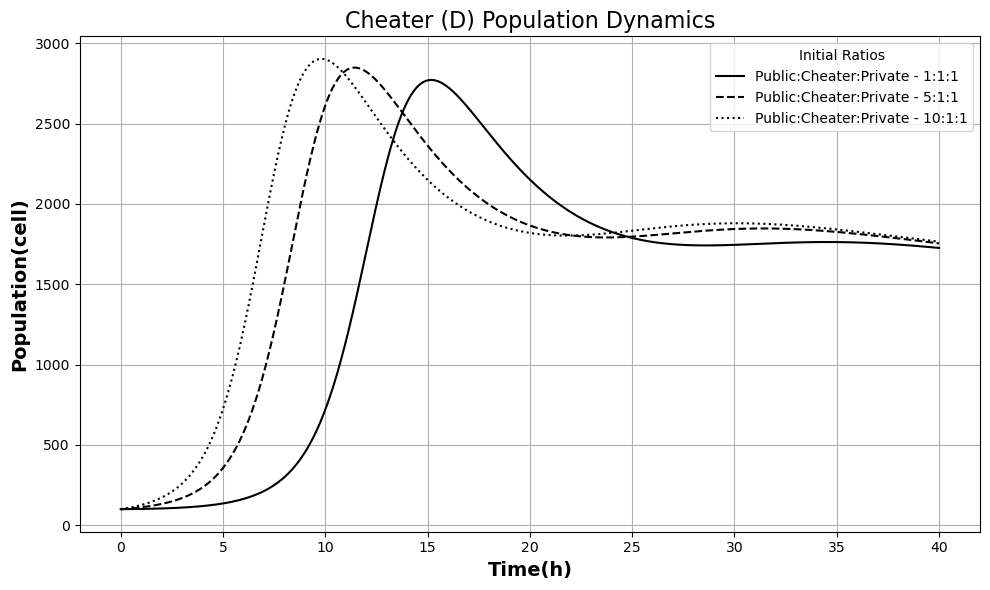

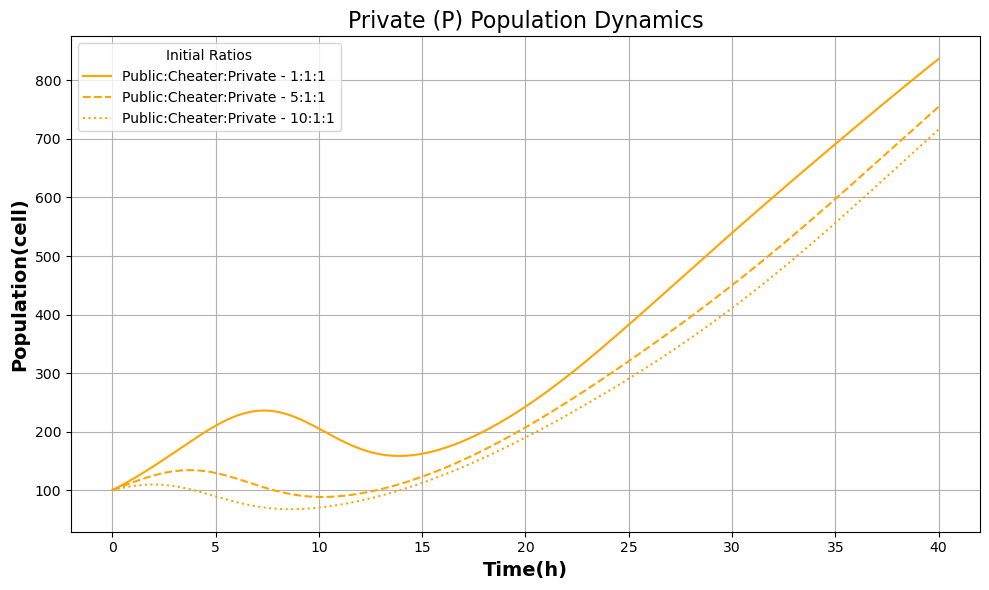

In [9]:
t_updated = np.linspace(0, 40, 1000)
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

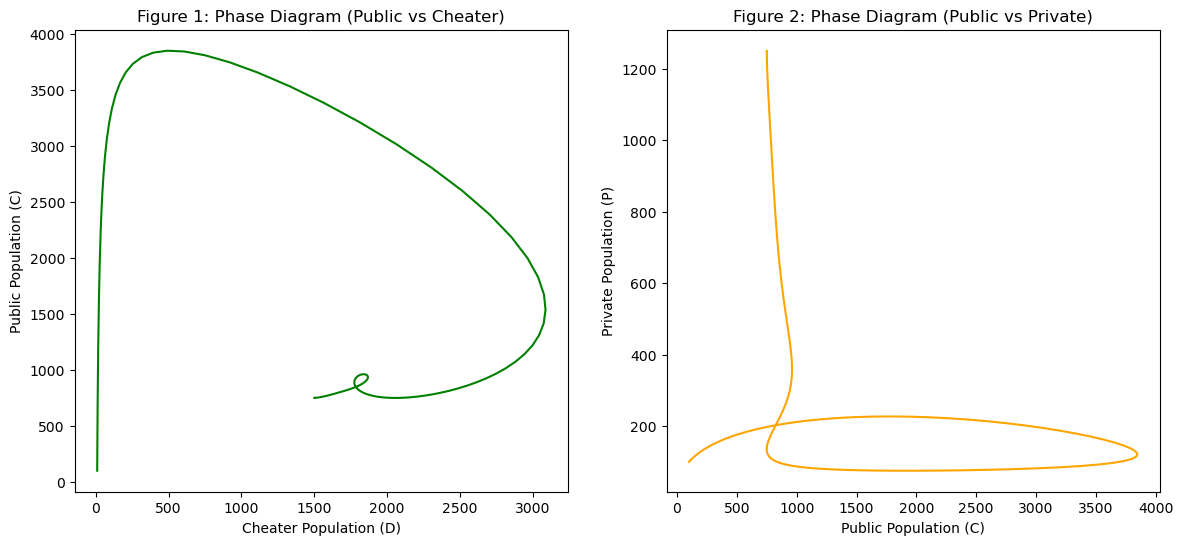

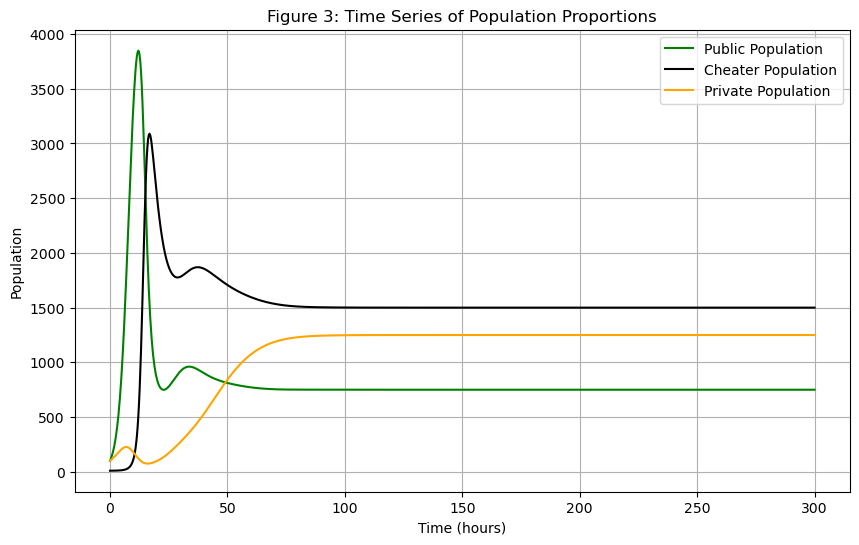

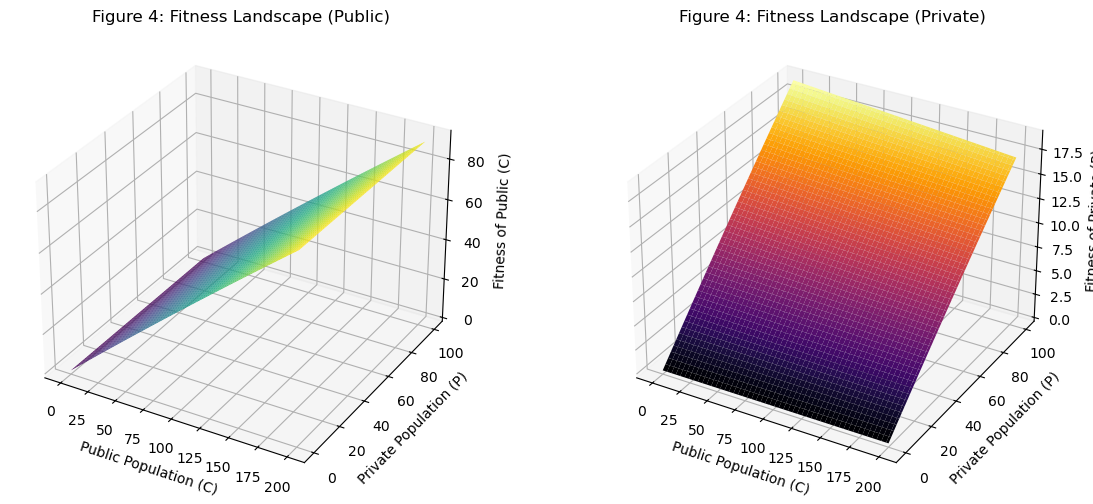

In [6]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

# Initial conditions and time grid
y0 = [100.0, 10.0, 100.0]  # Initial populations: [Public, Cheater, Private]
t = np.linspace(0, 300, 1000)  # Time grid

# Solve the ODE system
ret = odeint(deriv, y0, t, args=(
    parameters["nu"],
    parameters["beta"],
    parameters["alpha"],
    parameters["r_c"],
    parameters["r_p"],
    parameters["gamma"],
    parameters["eta"],
))

# Extract the equilibrium point
equilibrium_point = ret[-1]

# Calculate Jacobian matrix and eigenvalues
def jacobian(y, nu, beta, alpha, r_c, r_p, gamma, eta):
    """
    Calculate the Jacobian matrix at a given point.
    """
    C, D, P = y
    J = np.array([
        [r_c - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, r_p - beta * C - 2 * gamma * P]
    ])
    return J

Jacobian_matrix = jacobian(equilibrium_point, parameters["nu"], parameters["beta"],
                            parameters["alpha"], parameters["r_c"], parameters["r_p"],
                            parameters["gamma"], parameters["eta"])

eigenvalues = eigvals(Jacobian_matrix)

# Phase Diagrams
def plot_phase_diagrams():
    """
    Plot phase diagrams for population dynamics.
    """
    C, D, P = ret.T
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Phase diagram: C vs D
    axes[0].plot(D, C, 'g')
    axes[0].set_xlabel('Cheater Population (D)')
    axes[0].set_ylabel('Public Population (C)')
    axes[0].set_title('Figure 1: Phase Diagram (Public vs Cheater)')

    # Phase diagram: C vs P
    axes[1].plot(C, P, 'orange')
    axes[1].set_xlabel('Public Population (C)')
    axes[1].set_ylabel('Private Population (P)')
    axes[1].set_title('Figure 2: Phase Diagram (Public vs Private)')

    plt.show()

# Time Series
def plot_time_series():
    """
    Plot the time series of population dynamics.
    """
    C, D, P = ret.T
    plt.figure(figsize=(10, 6))
    plt.plot(t, C, 'g', label='Public Population')
    plt.plot(t, D, 'black', label='Cheater Population')
    plt.plot(t, P, 'orange', label='Private Population')
    plt.xlabel('Time (hours)')
    plt.ylabel('Population')
    plt.title('Figure 3: Time Series of Population Proportions')
    plt.legend()
    plt.grid(True)
    plt.show()

# Fitness Landscapes
def plot_fitness_landscape():
    """
    Plot fitness landscapes for Public (C) and Private (P) populations.
    """
    C_vals = np.linspace(0, 200, 100)
    P_vals = np.linspace(0, 100, 100)
    C_mesh, P_mesh = np.meshgrid(C_vals, P_vals)
    D_mesh = 100  # Assume fixed D for simplicity

    # Compute fitness landscapes
    fitness_C = parameters["r_c"] * C_mesh - parameters["alpha"] * C_mesh * D_mesh - \
                parameters["beta"] * C_mesh * P_mesh - parameters["gamma"] * C_mesh**2
    fitness_P = parameters["r_p"] * P_mesh - parameters["beta"] * C_mesh * P_mesh - \
                parameters["gamma"] * P_mesh**2

    fig = plt.figure(figsize=(14, 6))

    # Fitness for Public (C)
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(C_mesh, P_mesh, fitness_C, cmap='viridis')
    ax1.set_xlabel('Public Population (C)')
    ax1.set_ylabel('Private Population (P)')
    ax1.set_zlabel('Fitness of Public (C)')
    ax1.set_title('Figure 4: Fitness Landscape (Public)')

    # Fitness for Private (P)
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(C_mesh, P_mesh, fitness_P, cmap='inferno')
    ax2.set_xlabel('Public Population (C)')
    ax2.set_ylabel('Private Population (P)')
    ax2.set_zlabel('Fitness of Private (P)')
    ax2.set_title('Figure 4: Fitness Landscape (Private)')

    plt.show()

# Execute plots
plot_phase_diagrams()
plot_time_series()
plot_fitness_landscape()


# 2. Using variour growth rate

# 3. Stochastic dynamics in growth rate
adding noise in growth condition

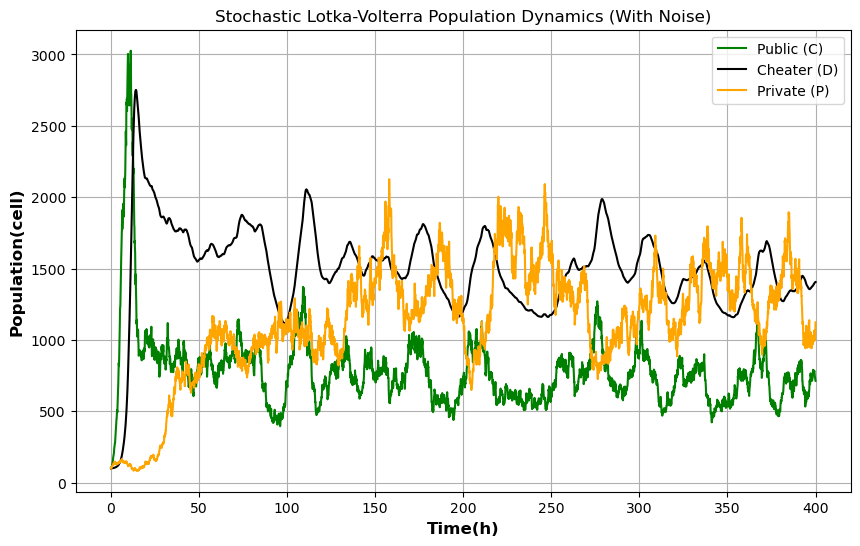

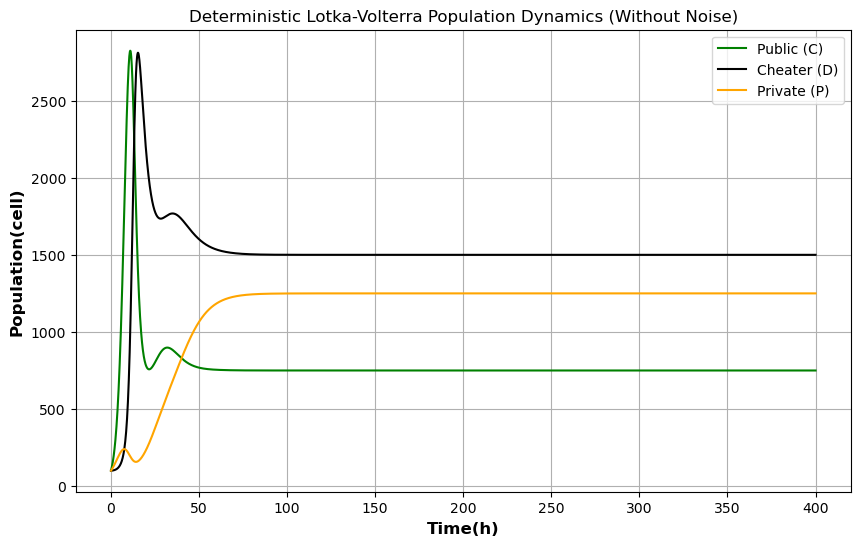

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import parameters

# Simulation Function
def simulate_population(T, dt, C0, D0, P0, params, noise=True):
    # Simulation parameters
    n_steps = int(T / dt)
    time = np.linspace(0, T, n_steps)

    # Arrays to store population values
    C = np.zeros(n_steps)
    D = np.zeros(n_steps)
    P = np.zeros(n_steps)

    # Initial values
    C[0], D[0], P[0] = C0, D0, P0

    # Euler-Maruyama Simulation Loop
    for t in range(1, n_steps):
        dW_c = np.random.normal(0, np.sqrt(dt)) if noise else 0
        dW_p = np.random.normal(0, np.sqrt(dt)) if noise else 0
        
        # Stochastic differential equations
        dC = (params["r_c"] * C[t-1] - params["alpha"] * C[t-1] * D[t-1] - params["beta"] * C[t-1] * P[t-1] - params["eta"] * C[t-1]**2) * dt \
             + params["sigma_c"] * C[t-1] * dW_c
        dD = (params["alpha"] * C[t-1] * D[t-1] - params["nu"] * D[t-1]**2) * dt
        dP = (params["r_p"] * P[t-1] - params["beta"] * P[t-1] * C[t-1] - params["gamma"] * P[t-1]**2) * dt \
             + params["sigma_p"] * P[t-1] * dW_p

        # Update populations
        C[t] = max(C[t-1] + dC, 0)
        D[t] = max(D[t-1] + dD, 0)
        P[t] = max(P[t-1] + dP, 0)

    return time, C, D, P

# Run the simulations
T = 400    # Total time
dt = 0.1   # Time step
C0, D0, P0 = 100, 100, 100  # Initial conditions

# Simulate with noise
time, C_noise, D_noise, P_noise = simulate_population(T, dt, C0, D0, P0, parameters, noise=True)

# Plot with noise
plt.figure(figsize=(10, 6))
plt.plot(time, C_noise, label='Public (C)', color='green')
plt.plot(time, D_noise, label='Cheater (D)', color='black')
plt.plot(time, P_noise, label='Private (P)', color='orange')
plt.title('Stochastic Lotka-Volterra Population Dynamics (With Noise)')
plt.xlabel('Time(h)', fontsize=12, fontweight='bold')
plt.ylabel('Population(cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

# Simulate without noise
time, C_det, D_det, P_det = simulate_population(T, dt, C0, D0, P0, parameters, noise=False)

# Plot without noise
plt.figure(figsize=(10, 6))
plt.plot(time, C_det, label='Public (C)', color='green')
plt.plot(time, D_det, label='Cheater (D)', color='black')
plt.plot(time, P_det, label='Private (P)', color='orange')
plt.title('Deterministic Lotka-Volterra Population Dynamics (Without Noise)')
plt.xlabel('Time(h)', fontsize=12, fontweight='bold')
plt.ylabel('Population(cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


# sensivity analysis

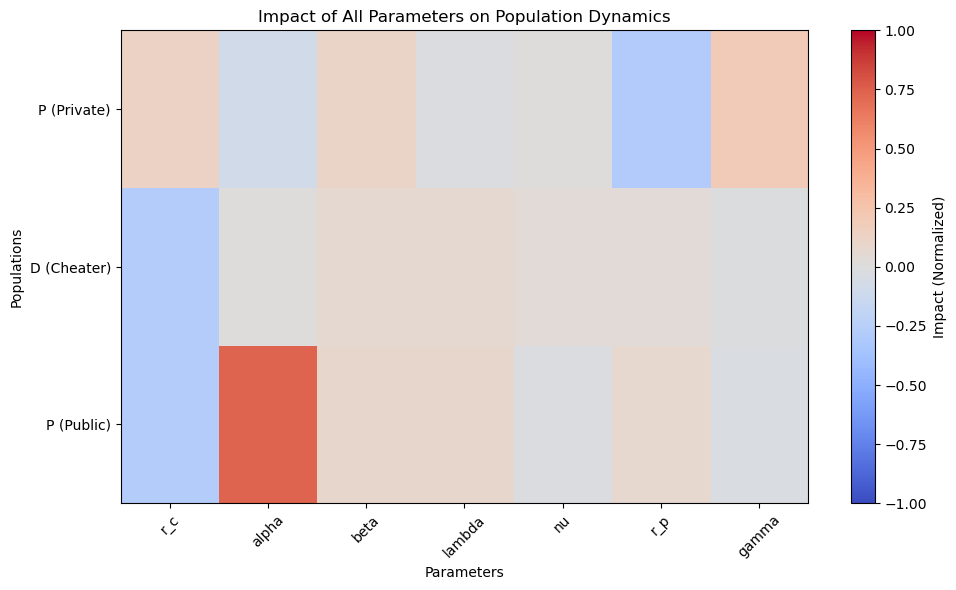

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and ranges
parameters = {
    'r_c': 0.04,
    'alpha': 0.0002,
    'beta': 0.0001,
    'lambda': 0.0001,
    'nu': 0.00001,
    'r_p': 0.02,
    'gamma': 0.0001,
}

# Initial conditions
C0, D0, P0 = 100, 100, 100  # Initial populations
t_max = 100  # Simulation time
dt = 0.1  # Time step
n_steps = int(t_max / dt)

# Function to simulate population dynamics
def calculate_population_dynamics(params):
    C, D, P = C0, D0, P0
    total_C, total_D, total_P = 0, 0, 0

    for _ in range(n_steps):
        # Differential equations
        dC = params['r_c'] * C - params['alpha'] * C * D - params['beta'] * C * P - params['lambda'] * C**2
        dD = params['alpha'] * C * D - params['nu'] * D**2
        dP = params['r_p'] * P - params['beta'] * P * C - params['gamma'] * P**2

        # Update populations
        C += dC * dt
        D += dD * dt
        P += dP * dt

        # Accumulate positive populations
        total_C += max(C, 0) * dt
        total_D += max(D, 0) * dt
        total_P += max(P, 0) * dt

    return total_C, total_D, total_P

# Baseline dynamics
baseline_C, baseline_D, baseline_P = calculate_population_dynamics(parameters)

# Parameter perturbation range
rc_rp_range = np.linspace(2, 1.0, 10)  # Range for parameters

# Initialize impact matrix
parameter_names = list(parameters.keys())
impact_matrix = np.zeros((3, len(parameter_names)))  # Rows: Populations, Columns: Parameters

# Metabolic control analysis
for j, param_name in enumerate(parameter_names):
    impacts = []

    for factor in rc_rp_range:
        perturbed_params = parameters.copy()
        perturbed_params[param_name] *= factor
        perturbed_C, perturbed_D, perturbed_P = calculate_population_dynamics(perturbed_params)

        # Calculate relative impacts for populations
        impacts.append([
            (baseline_C - perturbed_C) /  perturbed_C,
            (baseline_D - perturbed_D) / perturbed_D ,
            (baseline_P - perturbed_P ) / perturbed_P,
        ])

    # Average impact over the range
    impact_matrix[:, j] = np.mean(impacts, axis=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(impact_matrix, aspect='auto', cmap='coolwarm', origin='lower', vmin= -1, vmax=1)
plt.colorbar(label='Impact (Normalized)')
plt.xticks(range(len(parameter_names)), labels=parameter_names, rotation=45)
plt.yticks(range(3), labels=['P (Public)', 'D (Cheater)', 'P (Private)'])
plt.title('Impact of All Parameters on Population Dynamics')
plt.xlabel('Parameters')
plt.ylabel('Populations')
plt.tight_layout()
plt.show()


# Alpha and beta ratio

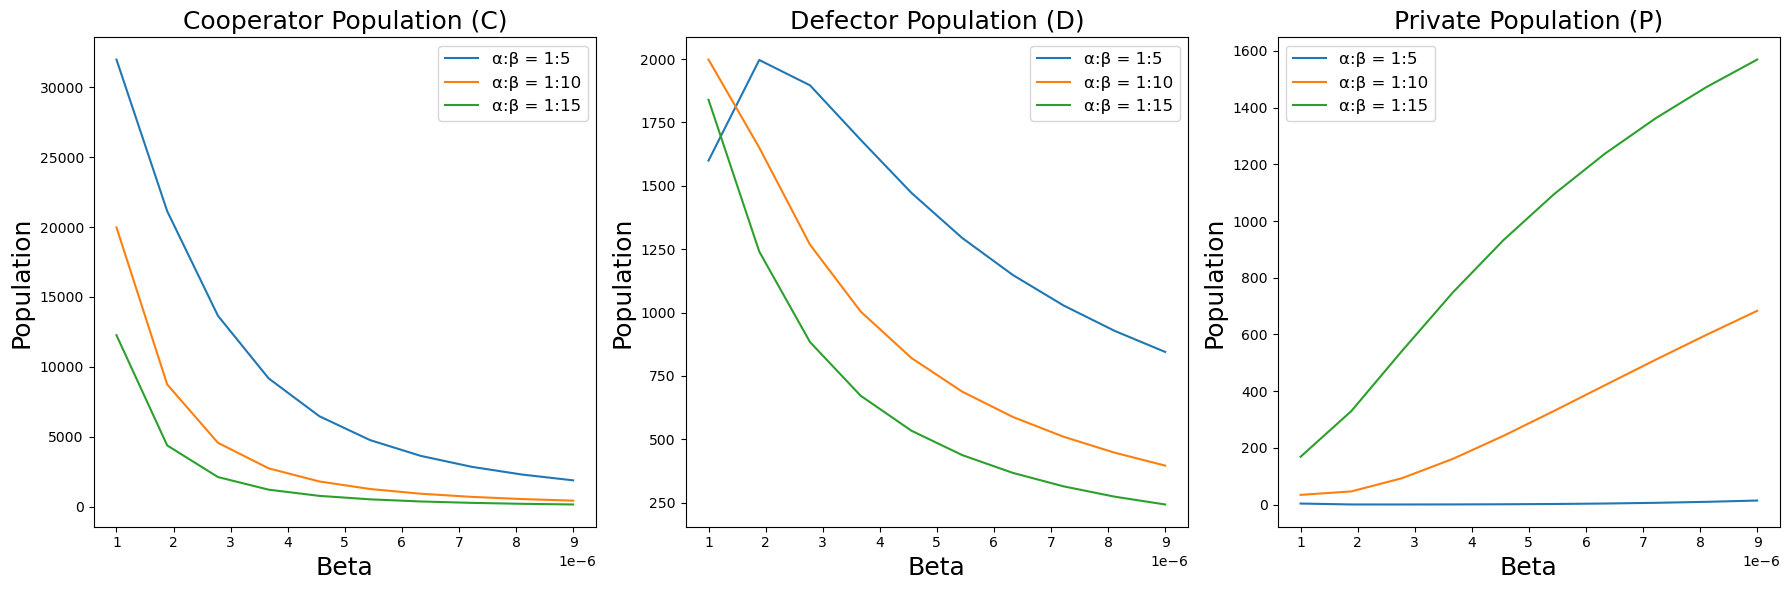

In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - gamma * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
gamma = 0.000001  # cost spent by private population
mu = 0.04       # growth rate of cooperator
eta = 0.02      # growth rate of private
nu = 0.0001    # transportation cost of defector

# Initial conditions
C0, D0, P0 = 1000.0, 10.0, 10.0  # initial populations
y0 = [C0, D0, P0]

# Time grid
t = np.linspace(0, 300, 1000)

# Alpha-to-beta ratios
ratios = [5, 10, 15]  # Example ratios of alpha to beta
beta_values = np.linspace(0.000001, 0.000009, 10)  # Independent parameter

# Preallocate arrays to store steady-state populations
results = {ratio: {"C": [], "D": [], "P": []} for ratio in ratios}

# Loop over ratios
for ratio in ratios:
    for beta in beta_values:
        alpha = ratio * beta  # Calculate alpha based on the fixed ratio
        # Solve the ODE system
        sol = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
        C, D, P = sol.T
        
        # Store the final (steady-state) populations
        results[ratio]["C"].append(C[-1])
        results[ratio]["D"].append(D[-1])
        results[ratio]["P"].append(P[-1])

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

fontsize = 18
for i, (pop, title, color) in enumerate(zip(
    ["C", "D", "P"], 
    ["Cooperator Population (C)", "Defector Population (D)", "Private Population (P)"],
    ["viridis", "plasma", "inferno"]
)):
    for ratio in ratios:
        axs[i].plot(beta_values, results[ratio][pop], label=f"α:β = 1:{ratio}")
    axs[i].set_title(title, fontsize=fontsize)
    axs[i].set_xlabel('Beta', fontsize=fontsize)
    axs[i].set_ylabel('Population', fontsize=fontsize)
    axs[i].legend(fontsize=12)

plt.tight_layout()
plt.show()


# Experimental data analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from src.parameters import parameters

# Define the System of ODEs
def deriv(t, y, params):
    C, D, P = y

    # Population Dynamics Equations
    dC = (params["r_c"] * C 
          - params["alpha"] * C * D  
          - params["eta"] * C**2)

    dD = (params["alpha"] * C * D 
          - params["nu"] * D**2)

    dP = (params["r_p"] * P 
          - params["beta"] * P * C 
          - params["gamma"] * P**2)

    return [dC, dD, dP]

# Simulation Parameters
T = 15                # Total simulation time
C0, D0, P0 = 1, 1, 1  # Initial populations
initial_conditions = [C0, D0, P0]
time = np.linspace(0, T, 1000)  # Time points for evaluation

# Solve the ODE System
solution = solve_ivp(
    deriv, [0, T], initial_conditions, t_eval=time, args=(parameters,), method="RK45"
)

# Extract Results
C_sol, D_sol, P_sol = solution.y


file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'

# Read the second Excel file into a DataFrame
df3 = pd.read_excel(file_path3)

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # First column (time)
last_column_3 = df3.iloc[:, -1]  # Last column (data to plot)


# Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(time, C_sol, label='Public (C)', color='blue')

# Plot the data from the second file (4018 C. glutamicum + 4056 E. coli)
plt.plot(first_column_3.iloc[:46], last_column_3.iloc[:46], label='4056 E. coli-coculture', color='g', marker="o", linestyle="None")


plt.title('Lotka-Volterra Population Dynamics')
plt.xlabel('Time (h)', fontsize=12, fontweight='bold')
plt.ylabel('Population (cells)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
df3.iloc[:46]

,Time [h],Count 4018 C. glutamicum [-]\nChamber 01,Count 4018 C. glutamicum [-]\nChamber 02,Count 4018 C. glutamicum [-]\nChamber 03,Count 4018 C. glutamicum [-]\nChamber 04,Count 4018 C. glutamicum [-]\nChamber 05,Count 4018 C. glutamicum [-]\nChamber 06,Count 4018 C. glutamicum [-]\nChamber 07,Count 4018 C. glutamicum [-]\nChamber 08,Count 4018 C. glutamicum [-]\nChamber 09,...,Count 4056 E. coli WT [-]\nChamber 02,Count 4056 E. coli WT [-]\nChamber 03,Count 4056 E. coli WT [-]\nChamber 04,Count 4056 E. coli WT [-]\nChamber 05,Count 4056 E. coli WT [-]\nChamber 06,Count 4056 E. coli WT [-]\nChamber 07,Count 4056 E. coli WT [-]\nChamber 08,Count 4056 E. coli WT [-]\nChamber 09,Count 4056 E. coli WT [-]\nChamber 10,Average count 4056 E.coli WT [-]\nChamber 01-10
0,0.000000,11,20,15,13,14,8,15,7,14,...,2,2,2,4,2,2,1,2,2.0,2.4
1,0.333333,11,19,18,17,20,13,18,7,20,...,2,2,2,4,2,2,1,3,2.0,2.6
2,0.666667,14,27,28,18,22,15,23,11,23,...,2,3,2,5,2,2,1,3,2.0,2.7
3,1.000000,15,34,26,23,31,20,26,13,27,...,2,2,3,6,2,2,1,4,1.0,3.0
4,1.333333,18,40,27,24,41,22,31,14,37,...,3,2,4,8,4,3,1,4,2.0,3.9
5,1.666667,23,51,35,24,42,27,36,17,38,...,3,2,4,8,4,4,2,4,2.0,4.2
6,2.000000,28,60,45,27,52,32,48,20,46,...,4,3,4,8,4,4,3,4,2.0,4.5
7,2.333333,28,66,45,27,64,39,55,21,55,...,5,4,4,9,4,6,5,7,3.0,5.7
8,2.666667,34,72,47,34,75,40,57,21,63,...,7,4,4,10,7,5,7,8,2.0,6.7
9,3.000000,40,77,49,34,82,43,61,30,74,...,7,4,4,13,8,5,6,8,3.0,7.1


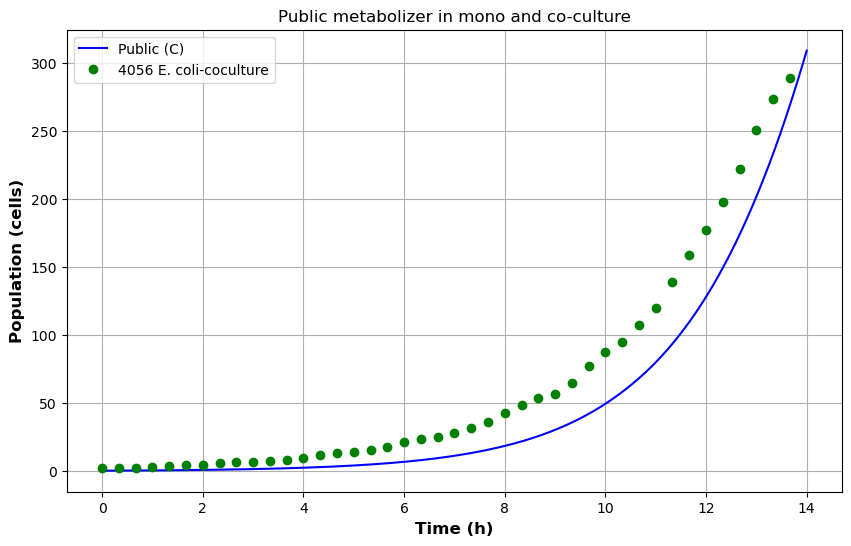

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from src.parameters import parameters

# Define the System of ODEs
def deriv(t, y, params):
    C, D, P = y

    # Population Dynamics Equations
    dC = (params["r_c"] * C 
          - params["alpha"] * C * D  
          - params["eta"] * C**2)

    dD = (params["alpha"] * C * D 
          - params["nu"] * D**2)

    dP = (params["r_p"] * P 
          - params["beta"] * P * C 
          - params["gamma"] * P**2)

    return [dC, dD, dP]

# Simulation Parameters
T = 14                # Total simulation time
C0, D0, P0 = 1, 1, 1  # Initial populations
initial_conditions = [C0, D0, P0]
time = np.linspace(0, T, 1000)  # Time points for evaluation

# Solve the ODE System
solution = solve_ivp(
    deriv, [0, T], initial_conditions, t_eval=time, args=(parameters,), method="RK45"
)

# Extract Results
C_sol, D_sol, P_sol = solution.y

# Read the experimental data
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'
df3 = pd.read_excel(file_path3)

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # First column (time)
last_column_3 = df3.iloc[:, -1]  # Last column (data to plot)

# Find the maximum value in the experimental data
max_value = last_column_3.max()

# Normalize the simulation results by the maximum value of the experimental data
C_sol_normalized = C_sol / C_sol.max() * max_value
D_sol_normalized = D_sol / D_sol.max() * max_value
P_sol_normalized = P_sol / P_sol.max() * max_value

# Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(time, C_sol_normalized, label='Public (C)', color='blue')

# Plot the data from the second file (4018 C. glutamicum + 4056 E. coli)
plt.plot(first_column_3.iloc[:42], last_column_3.iloc[:42], label='4056 E. coli-coculture', color='g', marker="o", linestyle="None")

plt.title('Public metabolizer in mono and co-culture')
plt.xlabel('Time (h)', fontsize=12, fontweight='bold')
plt.ylabel('Population (cells)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


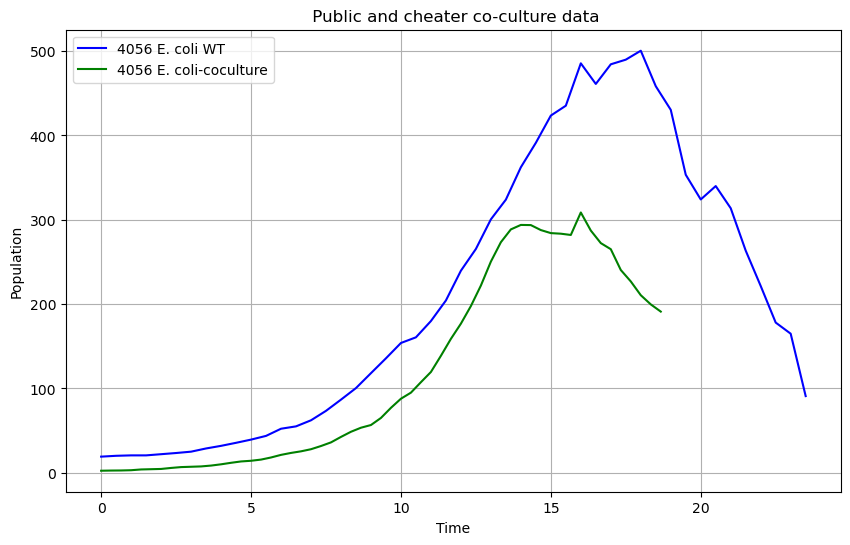

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Provide the correct file paths
file_path1 = r'C:\Users\Tanvir Hassan\4056 E.coli WT.xlsx'
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'

# Read the first Excel file into a DataFrame
df1 = pd.read_excel(file_path1)

# Select the first and last columns from the first file
first_column_1 = df1.iloc[:, 0]  # First column (time)
last_column_1 = df1.iloc[:, -1]  # Last column (data to plot)

# Read the second Excel file into a DataFrame
df3 = pd.read_excel(file_path3)

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # First column (time)
last_column_3 = df3.iloc[:, -1]  # Last column (data to plot)

# Create a plot
plt.figure(figsize=(10, 6))

# Plot the data from the first file (4056 E. coli)
plt.plot(first_column_1, last_column_1, label='4056 E. coli WT', color='b')

# Plot the data from the second file (4018 C. glutamicum + 4056 E. coli)
plt.plot(first_column_3, last_column_3, label='4056 E. coli-coculture', color='g')

# Add labels and title
plt.xlabel('Time')
plt.ylabel('Population')
plt.title(' Public and cheater co-culture data')

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Show the plot
plt.show()

# optimizer (data fitting practice)

Optimization success: True
Optimization message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Fitted parameter values: [1.05801038e-04 1.00045747e-04 3.46774251e-03 9.46829445e-04
 4.76267874e-01 1.99999768e-01 6.35485459e-03 1.00000000e-01
 1.00000010e-01]


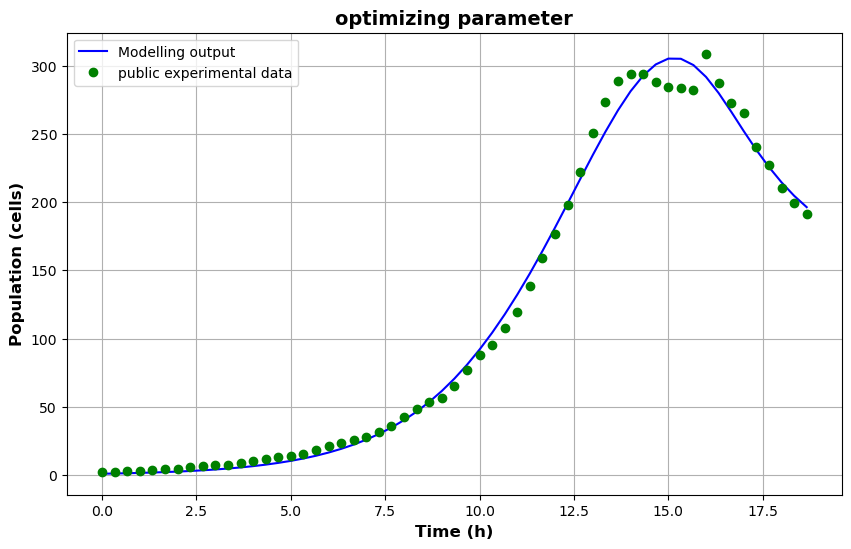

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from src.parameters import parameters  # my parameters dictionary

# ODE system
def deriv(t, y, params):
    C, D, P = y
    dC = (params["r_c"] * C 
          - params["alpha"] * C * D  
          - params["eta"] * C**2)
    dD = (params["alpha"] * C * D 
          - params["nu"] * D**2)
    dP = (params["r_p"] * P 
          - params["beta"] * P * C 
          - params["gamma"] * P**2)
    return [dC, dD, dP]

# Load experimental data
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'
df3 = pd.read_excel(file_path3)

# Experimental data and time
time_data = df3.iloc[:, 0].values        # time points from data
exp_data = df3.iloc[:, -1].values        # experimental population data

# Initial conditions for ODE simulation
C0, D0, P0 = 1, 1, 1
initial_conditions = [C0, D0, P0]

# Residual function for optimization
def residual(param_values, data, model):
    

    # Update the parameters dictionary with the new values
    param_keys = list(model.keys())
    for i, key in enumerate(param_keys):
        model[key] = param_values[i]

    # Solve the ODE system using updated parameters
    sol = solve_ivp(
        deriv, [time_data[0], time_data[-1]], initial_conditions, t_eval=time_data, args=(model,), method='RK45'
    )

    if not sol.success:
        # If the solver fails, return a large error
        return 1e6

    # Extract predicted results (e.g., C population)
    C_pred = sol.y[0]

    # Compute error (data - prediction)
    error = data - C_pred

    # Calculate root mean square error
    rmse = np.sqrt(np.mean(error**2))
    return rmse

# Initial guess for parameters
initial_guess = list(parameters.values())

# Minimize the residual function
sol = minimize(residual, x0=initial_guess, args=(exp_data, parameters), method='L-BFGS-B')

# Check if the optimization was successful
print("Optimization success:", sol.success)
print("Optimization message:", sol.message)
print("Fitted parameter values:", sol.x)

# Update parameters with fitted values
fitted_params = dict(zip(parameters.keys(), sol.x))

# Run the model again with fitted parameters to visualize the fit
fitted_solution = solve_ivp(
    deriv, [time_data[0], time_data[-1]], initial_conditions, t_eval=time_data, args=(fitted_params,), method='RK45'
)

C_sol_fitted = fitted_solution.y[0]

# Plot the fitted model vs experimental data
plt.figure(figsize=(10,6))
plt.plot(time_data, C_sol_fitted, label='Modelling output', color='blue')
plt.plot(time_data, exp_data, label='public experimental data', color='green', marker='o', linestyle='None')
plt.xlabel('Time (h)', fontsize=12, fontweight='bold')
plt.ylabel('Population (cells)', fontsize=12, fontweight='bold')
plt.title('optimizing parameter', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


In [30]:
fitted_params = dict(zip(parameters.keys(), sol.x))

# Print fitted parameters 
print("Fitted Parameters:")
for name, val in fitted_params.items():
    print(f"{name}: {val}")

Fitted Parameters:
beta: 0.0018145503499761287
gamma: 9.513368336024696e-05
alpha: 0.003484462168035931
eta: 0.0009445800624138131
r_c: 0.47634136166110763
r_p: -14.206370990009935
nu: 0.006451458957294355
sigma_c: 0.7212802823872798
sigma_p: 9.533984873463897
